In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio.warp
import scipy.ndimage

In [2]:
FEET_PER_METER = 3.2808398950131

GULLY_SLICE = (slice(7800, 8750), slice(7750, 8500))
ANOTHER_SLICE = (slice(4000, 8000), slice(4000, 8000))

In [3]:
with rasterio.open("../dutch-bill-2022.tif") as file:
    elevation2022 = file.read(1)
    main_transform = file.transform
    main_crs = file.crs
    mask2022 = abs(elevation2022) < 1e30  # True for valid pixels

In [4]:
with rasterio.open("../dutch-bill-2013.tif") as file:
    tmp_original = file.read(1)
    tmp_mask = (tmp_original != file.nodata).astype(np.float32)

    elevation2013 = np.empty(elevation2022.shape, dtype=tmp_original.dtype)
    rasterio.warp.reproject(
        source=tmp_original,
        destination=elevation2013,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=main_transform,
        dst_crs=main_crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    elevation2013 /= FEET_PER_METER

    mask = np.empty(elevation2022.shape, dtype=np.float32)
    rasterio.warp.reproject(
        source=tmp_mask,
        destination=mask,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=main_transform,
        dst_crs=main_crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    mask = mask > 0.5  # True for valid pixels
    mask &= mask2022

    del tmp_original
    del tmp_mask

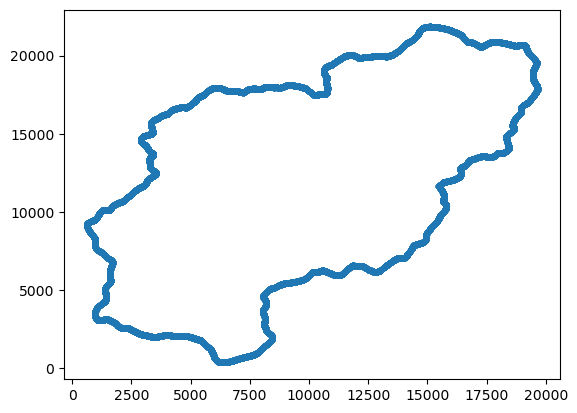

In [13]:
fig, ax = plt.subplots()

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~mask] = np.nan
tmp2013[~mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

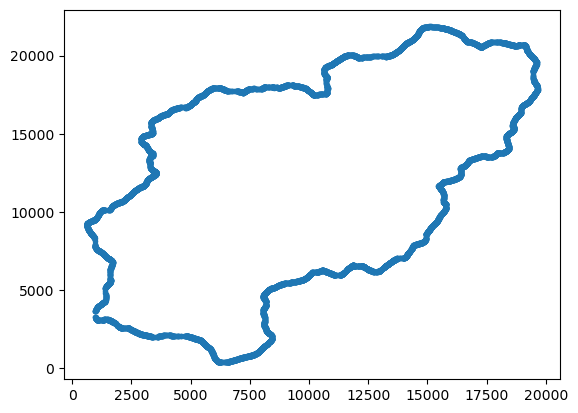

In [16]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=1)

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~tmp_mask] = np.nan
tmp2013[~tmp_mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

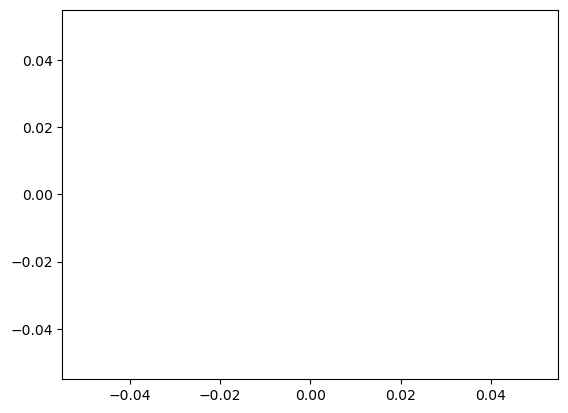

In [17]:
fig, ax = plt.subplots()

tmp_mask = scipy.ndimage.binary_erosion(mask, iterations=2)

tmp2022 = elevation2022.copy()
tmp2013 = elevation2013.copy()
tmp2022[~tmp_mask] = np.nan
tmp2013[~tmp_mask] = np.nan

ax.scatter(*np.nonzero(tmp2022 - tmp2013 > 100), marker=".")

None

In [26]:
mask_edges = (
    (np.roll(mask, -1, axis=0) != mask) |
    (np.roll(mask, 1, axis=0) != mask) |
    (np.roll(mask, -1, axis=1) != mask) |
    (np.roll(mask, 1, axis=1) != mask)
)

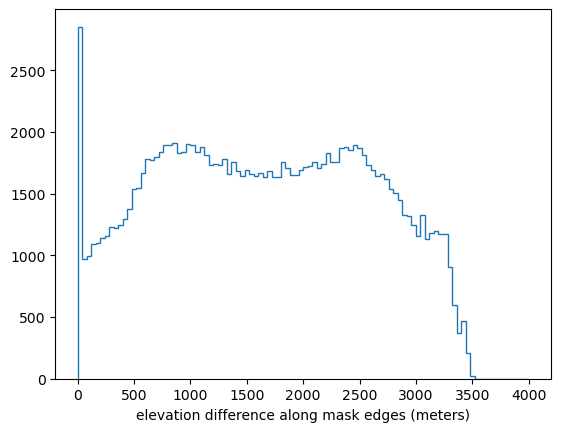

In [34]:
fig, ax = plt.subplots()

ax.hist(elevation2022[mask_edges] - elevation2013[mask_edges], bins=100, range=(0, 4000), histtype="step")

ax.set_xlabel("elevation difference along mask edges (meters)")

None

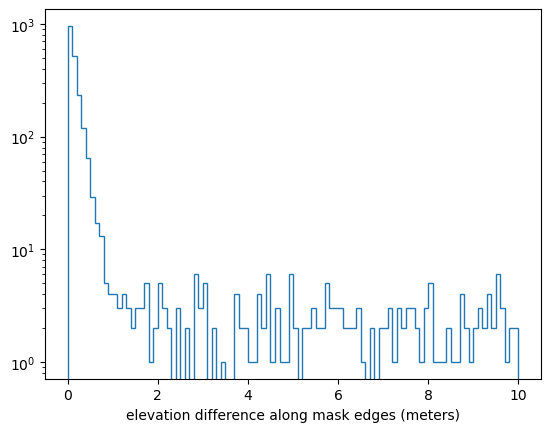

In [35]:
fig, ax = plt.subplots()

ax.hist(elevation2022[mask_edges] - elevation2013[mask_edges], bins=100, range=(0, 10), histtype="step")

ax.set_yscale("log")
ax.set_xlabel("elevation difference along mask edges (meters)")

None